# Radar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sarpy.io.phase_history.cphd import CPHDReader

from numpy.fft import fftshift, ifftshift
from scipy.fftpack import fft, ifft

from IPython.display import YouTubeVideo

## Fundamentals

### Radar Range Equation

The **radar range equation** describes the relationship between transmitted power, target characteristics, and the received signal power for a monostatic radar (co-located transmitter and receiver):

$$P_r = \frac{P_t G^2 \lambda^2 \sigma}{(4\pi)^3 R^4 L}$$

where:

| Variable | Description |
|----------|-------------|
| $P_r$ | Received signal power (W) |
| $P_t$ | Transmitted power (W) |
| $G$ | Antenna gain (linear) |
| $\lambda$ | Wavelength of the transmitted signal (m) |
| $\sigma$ | Radar cross-section (RCS) of the target (m$^2$) |
| $R$ | Range to the target (m) |
| $L$ | System losses (linear, $\geq 1$) |

The $R^4$ dependence is a key characteristic: the signal must travel to the target _and_ back, suffering $1/R^2$ free-space path loss in each direction. This means that doubling the range requires 16$\times$ (roughly +12 dB) the transmit power to maintain the same received signal level.

For detection, $P_r$ must exceed the receiver noise floor by some minimum signal-to-noise ratio (SNR). Rearranging for maximum detectable range:

$$R_{\max} = \left[ \frac{P_t G^2 \lambda^2 \sigma}{(4\pi)^3 k T_s B_n \cdot \text{SNR}_{\min} \cdot L} \right]^{1/4}$$

where $k$ is Boltzmann's constant, $T_s$ is the system noise temperature (K), and $B_n$ is the receiver noise bandwidth (Hz).

## Pulsed Radar

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 1.8)
ax.axis('off')

# Pulse parameters
pw = 0.4        # Pulse Width
pri = 2.0       # Pulse Repetition Interval
num_pulses = 5  # Number of pulses in CPI

# Draw pulses
for i in range(num_pulses):
    x0 = i * pri
    # Rising edge, top, falling edge, baseline to next pulse
    ax.fill_between([x0, x0 + pw], 0, 1, color='steelblue', alpha=0.8)
    if i < num_pulses - 1:
        ax.plot([x0 + pw, (i + 1) * pri], [0, 0], 'k-', lw=1.5)
    # Rising/falling edges
    ax.plot([x0, x0], [0, 1], 'k-', lw=1.5)
    ax.plot([x0 + pw, x0 + pw], [1, 0], 'k-', lw=1.5)
    ax.plot([x0, x0 + pw], [1, 1], 'k-', lw=1.5)

# Baseline
ax.plot([0, num_pulses * pri - pri + pw], [0, 0], 'k-', lw=1.5)

# PW annotation (on first pulse)
ax.annotate('', xy=(pw, 1.25), xytext=(0, 1.25),
            arrowprops=dict(arrowstyle='<->', color='tab:red', lw=1.5))
ax.text(pw / 2, 1.35, r'$\tau$ (PW)', ha='center', fontsize=10, color='tab:red')

# PRI annotation (between first two pulses)
ax.annotate('', xy=(pri, -0.25), xytext=(0, -0.25),
            arrowprops=dict(arrowstyle='<->', color='tab:green', lw=1.5))
ax.text(pri / 2, -0.45, 'PRI', ha='center', fontsize=10, color='tab:green')

# CPI annotation (full span)
cpi_end = (num_pulses - 1) * pri + pw
ax.annotate('', xy=(cpi_end, 1.55), xytext=(0, 1.55),
            arrowprops=dict(arrowstyle='<->', color='tab:purple', lw=1.5))
ax.text(cpi_end / 2, 1.65, 'CPI', ha='center', fontsize=10, color='tab:purple',
        fontweight='bold')

ax.set_title('Pulsed Radar Timing', fontsize=12)
plt.tight_layout()
plt.show()

## Frequency-Modulated Continuous-Wave (FMCW) Radar

### References

- [FMCW Radar - radartutorial.eu](https://www.radartutorial.eu/02.basics/Frequency%20Modulated%20Continuous%20Wave%20Radar.en.html)
- [FMCW Radar Part 1 - Ranging - Wireless Pi](https://wirelesspi.com/fmcw-radar-part-1-ranging/)
- [FMCW Range Doppler Notebook](https://colab.research.google.com/drive/1lmYojrI1X7sbctWFrS_61IRUMnzKjAsV)

In [ ]:
YouTubeVideo('G_tmNtP0gw8')

## Synthetic Aperture Radar (SAR)

Synthetic Aperture Radar (SAR) is the process of using specialized radar processing techniques for imaging. The "Synthetic Aperture" in SAR is so called due to the concept of creating the effect of a very long antenna using signal processing, along with aperture techniques similar to other optical engineering domains.

SAR is popular for remote sensing due to its four distinct principles:
1. An active SAR carries it's own illumination which means it can work equally well day or night.
2. Most common SAR frequencies can pass through clouds, smoke, and precipitation allowing imaging in adverse conditions. As well, some frequencies can even penetrate foliage or other materials.
3. Radio Frequency (RF) energy used in a SAR system scatters off materials in different ways than light; SAR can then be used as a complementary, or more discriminatory, information source with optical imaging.
4. SAR systems rely on complex phase information of the returned signals; not only can images be formed, but other important information such as target motion can be garnered from this data as well.

### SAR History

The most basic form of radar measures _range_ (by measuring time delay between signal transmission and reception of reflection from target/scatterer) and _direction_ (given knowledge of an antenna's pointing angle and directivity). The received Doppler shift can be used to measure a target's relative speed, but it was also found that Doppler could also be used to obtain finer resolution perpendicular to the beam direction. This concept is often credited to Carl Wiley of Goodyear Aerospace in 1951.

Since the raw collected radar data in a SAR system is unfocused, it takes further signal processing to turn into a usable image. Like a hologram, the essential information is contained in the phase of the data (a.k.a. phase history). Early systems used the principles of Fourier optics to transform phase history data recorded on film into images using lens that performed two-dimensional Fourier transforms and focusing. While novel, this analog process has been since replaced with digital processing and collection methods.

### SAR Modes

**NOTE:** images from [Radartutorial website](https://www.radartutorial.eu/20.airborne/ab08.en.html)

- **Stripmap:** Here the antenna is held in a constant pointing direction, usually perpendicular to the path of travel. The beam sweeps across the ground in a contiguous strip. The length of the imaged strip is related to how far the sensor platform moves. The azimuth resolution is directly related to antenna length.
![](./img/stripmap_mode.png)
- **Scan:** In this mode, the antenna is scanned (either mechanically or electrically) in range several times during a synthetic aperture. This creates a wider image swath at the cost of degraded azimuth resolution. Azimuth resolution is equal to Stripmap mode's azimuth resolution times the number of swaths scanned.
![](./img/scan_mode.png)
- **Spotlight:** This is the highest resolution mode, however it images the least area during a given time interval. The azimuth resolution is improved by increasing the angular extent during a synthetic aperture by scanning the antenna to hold on a given area of interest.
![](./img/spotlight_mode.png)
- **Bistatic:** When the transmitter and receiver are co-located, or are part of the same platform, this is known as _monostatic_ operation. When the transmitter and receiver are at different locations, or on different platforms, this is known as _bistatic_.
![](./img/bistatic_SAR.gif)
- **Inverse SAR (ISAR):** In the above modes, it's assumed the target is stationary and the SAR platform is moving. However the principles of SAR also work in "inverse" where the target is in motion, while the radar system is static. An example is tracking satellites from a fixed ground-based radar. This can also be generalized to where both target and SAR platform are moving, such as on a ship in heavy seas being imaged by an airborne SAR.
![](./img/ISAR_mode.png)
- **Interferometric SAR (InSAR):** here extra post-processing is performed to extract features such as terrain height, or displacement, from complex SAR images. Commonly this is done as two complex SAR images acquired at the same spatial positions (differential InSAR) or slightly different positions (terrain height InSAR). These two complex images are then conjugate multiplied which gives an interferogram with contours of equal displacement/elevation.
![](./img/InSAR.jpg)

### SAR Image Formation

We can use [Compensated Phase History Data (CPHD)](https://nsgreg.nga.mil/doc/view?i=4638), which is the lowest level of processing provided by most SAR satellites, to show image formation techniques. The "compensated" in CPHD means the data has been _motion compensated_ but not yet projected into a rectangular grid, nor image. Commercial providers like [Umbra](https://registry.opendata.aws/umbra-open-data/) and [Capella](https://registry.opendata.aws/capella_opendata/) graciously provide open data for research and testing!

Two very helpful walkthroughs of this same process are:
1. [Using CPHD by Example](https://github.com/capellaspace/jupyter-notebooks/blob/master/CPHD_by_Example.ipynb): Jupyter notebook by Capella Space
2. [Obtain a SAR stripmap image in fast and slow time from CPHD data](https://dsp.stackexchange.com/questions/99604/obtain-a-sar-stripmap-image-in-fast-and-slow-time-from-cphd-data): question in Signal Processing Stack Exchange

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from pathlib import Path

bucket_name = "capella-open-data"
cphd_file = "CAPELLA_C03_SM_CPHD_HH_20211229053627_20211229053631.cphd"
object_key_cphd = f"data/2021/12/29/{Path(cphd_file).stem}/{cphd_file}"

# Avoid re-downloading the ~1.3 GB CPHD if it's already on disk (local iteration
# or restored from the GitHub Actions cache). Capella's open bucket is anonymous.
if not Path(cphd_file).exists():
    s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    resp = s3.head_object(Bucket=bucket_name, Key=object_key_cphd)
    print(f"Downloading {resp['ContentLength'] / 1e6:.1f} MB from s3://{bucket_name}/{object_key_cphd}")
    s3.download_file(bucket_name, object_key_cphd, cphd_file)
else:
    print(f"Using cached local file: {cphd_file}")

Here we can use the helpful [SarPy Python library](https://github.com/ngageoint/sarpy) provided by the [National Geospatial-Intelligence Agency](https://www.nga.mil/) to read in and parse the CPHD file and it's metadata:

In [ ]:
cphd = CPHDReader(cphd_file)

In [ ]:
# full size of data in CPHD
cphd.data_size[0]

#### Motion Compensation & a Basic Range-Doppler Image

SAR is a _coherent_ imaging technique: an image only forms if returns from thousands of pulses add up with their phases aligned to a small fraction of a wavelength, and at X-band ($\lambda_c \approx 3$ cm) a "small fraction" means _millimeters_ of round-trip path. No platform traverses a mathematically ideal path, so every pulse is really transmitted from a slightly different position than the ideal aperture assumes. **Motion compensation (mocomp)** uses precisely _measured_ platform positions (GPS/INS on aircraft, precision orbit determination for satellites) to remove the known geometry-induced delay and phase variation, re-referencing every pulse to a common reference point.

The workhorse is the Fourier shift theorem. A return at round-trip delay $\tau$ shows up in a pulse's frequency-domain samples as a linear phase $s(f) = e^{-j2\pi f \tau}$, so multiplying by the conjugate linear phase built from the measured delay $\tau_{ref}$ to a chosen reference point,

$$s'(f) = s(f)\, e^{\,+j 2\pi f \tau_{ref}} = e^{-j 2\pi f (\tau - \tau_{ref})}$$

shifts the time origin so all delays are measured _relative to the reference point_. Applied per-pulse, this pins the reference point to zero delay with zero phase across the entire aperture. As seen from that point, the real wiggly flight path becomes a perfect one. (In sampled data this single complex multiply performs both the coarse "range alignment" and the fine sub-wavelength phase correction.)

The "C" in CPHD means Capella already compensated this data, but to a _per-pulse_ scene reference point (SRP) that slides along the ground under the beam during this stripmap collect. Imaging wants one _fixed_ reference, so the code below re-compensates every pulse to the center pulse's SRP: with $\tau_{old}$ the delay to the old per-pulse SRP and $\tau_{new}$ the delay to the fixed one, the correction factor is exactly the shift-theorem term $e^{-j2\pi f(\tau_{old} - \tau_{new})}$.

Why does this matter so much? Because after mocomp to a fixed point, a scatterer at slant-range offset $\Delta R$ and cross-range (along-track) offset $y$ has a differential delay that is, to a very good approximation, a constant plus a term _linear_ in slow time $t_p$ (platform speed $v$, range $R$):

$$\Delta\tau(t_p) \approx \underbrace{\frac{2 \Delta R}{c_0}}_{\text{constant} \rightarrow \text{range}} \; - \; \underbrace{\frac{2 v y}{c_0 R}\, t_p}_{\text{linear} \rightarrow \text{Doppler}} \; + \; \underbrace{\mathcal{O}(t_p^2, \ldots)}_{\text{residual migration}}$$

Two FFTs then sort every scatterer into its own cell gives the most basic **range-Doppler** image formation:

- One IFFT across frequency turns the constant term into **range** position, and
- One FFT across pulses turns the linear term into **Doppler** frequency $f_D = \frac{2 v}{\lambda_c} \frac{y}{R}$, which is just a scaled **cross-range** position.

The higher-order terms (range curvature / cell migration) are simply ignored here, which is why bright scatterers far from the SRP smear into streaks in the image below which yields the defect the image formation algorithms in the next section correct:

In [ ]:
# The XML data w/in the CPHD.
xml = cphd.cphd_meta.to_dict()

# The number of channels.
num_chan = xml['Data']['NumCPHDChannels']

if num_chan > 1:
    raise ValueError('I assume a channel index of zero in the code below.')

# The number of samples and pulses in the data.
Nrf = xml['Data']['Channels'][0]['NumSamples']
Npulse = xml['Data']['Channels'][0]['NumVectors']

# Get the PVP parameters.
pvp = {}
pnames = list( xml["PVP"].keys() )
for ii in pnames:
    pvp[ii] = np.ascontiguousarray(cphd.read_pvp_variable(ii, 0))

# Read in the phase history data.
mcph = cphd.read_chip()
    
# Get the SRP for the center pulse. We will motion
# compensate to this point.
srp0 = pvp['SRPPos'][Npulse//2,:].reshape((1,3))

# Compute the difference in delay between the SRP used on each pulse and new
# new motion compensation point. This ignores atmoshperic delays, details of
# which can be found in the CPHD documentation.
c0 = 299792458.0
delay_old = (np.sqrt(np.sum((pvp['TxPos'] - pvp['SRPPos'])**2, axis=1)) + np.sqrt(np.sum((pvp['RcvPos'] - pvp['SRPPos'])**2, axis=1))) / c0
delay_new = (np.sqrt(np.sum((pvp['TxPos'] - srp0)**2, axis=1)) + np.sqrt(np.sum((pvp['RcvPos'] - srp0)**2, axis=1))) / c0

# Compute the RF sample locations of the phase history data.
rf_locations = pvp['SC0'].reshape((Npulse,1)) + pvp['SCSS'].reshape((Npulse,1)) @ np.arange(0, Nrf, dtype=np.float64).reshape((1,Nrf))

# Re-motion compensate the data to a single point.
mcph_new = mcph * np.exp(-1j*2*np.pi * (delay_old - delay_new).reshape((Npulse,1)) * rf_locations, dtype=np.complex64)

# Form a range/Doppler image by taking the forward FFT in slow-time (pulse)
# and the inverse FFT in RF.
img = fftshift(ifft(fft(ifftshift(mcph_new), axis=0), axis=1))

# Estimate the range and Doppler sample locations.
prf = np.mean(1.0 / np.diff(pvp['TxTime']))
doppler_locations = prf/Npulse * (np.arange(0, Npulse, dtype=np.float64) - Npulse//2)

range_size = c0/2 / np.mean(np.diff(rf_locations, axis=1))
range_locations = range_size/Nrf * (np.arange(0, Nrf, dtype=np.float64) - Nrf//2)

# Put the magnitude of the image into decibels such that its
# max value is zero.
img_disp = 20*np.log10(np.abs(img) / np.abs(img).max())

# The coordinate extents.
dx = np.mean(np.diff(doppler_locations))
dy = np.mean(np.diff(range_locations))
extent = (doppler_locations[0] - dx/2,
          doppler_locations[-1] + dx/2,
          range_locations[-1] + dy/2,
          range_locations[0] - dy/2)

In [ ]:
# Display the image.
plt.ion()
plt.figure(figsize=(12,8), dpi=300)
plt.imshow(img_disp.T, vmin=-60, vmax=0, cmap='gray', extent=extent)
plt.xlabel('Doppler (Hertz)')
plt.ylabel('Range (meters)')

#### Focused Imaging & the k-Space View of SAR Data

The range-Doppler image above looks surprisingly decent because the heavy lifting was already done by the re-motion compensation: after referencing every pulse to a single scene point (the SRP), a scatterer's residual phase is _nearly_ linear in both RF frequency and slow time, so a plain 2-D FFT (nearly) focuses it. "Nearly" is the catch: scatterers away from the SRP migrate through range and Doppler cells over the aperture (_range cell migration_), which causes the smearing and streaking visible around bright targets toward the edges of the image above.

True _image formation algorithms_ (IFAs) correct this migration. Below we implement the two classic extremes of the speed-vs-accuracy tradeoff on the same CPHD data:

1. **Polar Format Algorithm (PFA):** computationally light, two passes of 1-D interpolation plus a single 2-D FFT.
2. **Backprojection (BP):** the image-quality "gold standard", an exact per-pixel matched filter with essentially no geometric approximations, at brute-force computational cost.

Both are easiest to understand in **k-space** (the spatial-frequency domain). Consider a scatterer at position offset $\vec{x}$ from the SRP, with the radar in the far field in direction $\hat{u}_p$ (the unit vector pointing from the SRP to the platform on pulse $p$, at range $R$). Its differential round-trip delay relative to the SRP is

$$\Delta\tau_p(\vec{x}) = \frac{2}{c_0}\left(\lvert R\,\hat{u}_p - \vec{x}\rvert - R\right) \approx -\frac{2}{c_0}\,\hat{u}_p\cdot\vec{x}$$

where the approximation (dropping terms of order $\lvert\vec{x}\rvert^2/R$) treats the incident wavefronts as planes, which is very reasonable from 643 km away. Each motion-compensated CPHD sample at RF frequency $f$ contains phase $e^{-j2\pi f \Delta\tau_p}$ from this scatterer, so summing over the scene's reflectivity:

$$s(p, f) \approx \sum_{\text{scatterers}} A\, e^{\,j\,\vec{k}\cdot\vec{x}}, \qquad \vec{k}(p, f) = \frac{4\pi f}{c_0}\,\hat{u}_p$$

In words: **every sample of the phase history is one sample of the scene's 2-D spatial Fourier transform**, taken at k-space location $\vec{k}(p,f)$. The RF frequency $f$ sets the radial coordinate $\lvert\vec{k}\rvert = 4\pi f/c_0$ and the platform look direction $\hat{u}_p$ sets the angular coordinate, so a collection fills in a thin **polar annulus** of k-space, one radial "spoke" per pulse. Image formation is then conceptually just an inverse 2-D Fourier transform. (The phase sign convention is nominally recorded in the CPHD `Global.SGN` metadata field; the $e^{-j2\pi f\Delta\tau}$ convention used here is the one that empirically matches this data; with the opposite sign, everything defocuses.)

Because resolution is inversely proportional to spatial-frequency extent, two fundamental SAR results fall straight out of the k-space picture:

$$\rho_r = \frac{c_0}{2B} \qquad \qquad \rho_a = \frac{\lambda_c}{2\,\Delta\theta}$$

- $\rho_r$: slant-range resolution, set by the RF bandwidth $B$ (the annulus' radial thickness).
- $\rho_a$: cross-range (azimuth) resolution, set by the angular aperture $\Delta\theta$ swept by the platform (the annulus' angular width) at center wavelength $\lambda_c$.

One stripmap-specific detail: the beam sweeps along the ground, so any given scene point is only illuminated for a fraction of the full 4 s collect (roughly 0.8 s here). Pulses whose beam footprint doesn't cover the SRP contribute nothing but noise to a patch around it, so we process a centered **subaperture**, the portion of the flight path that actually illuminates the SRP, and set up the imaging geometry relative to it:

In [ ]:
import gc
import time
import scipy.fft as sfft

# Free the largest intermediates from the basic range-Doppler image above --
# the focused processing below only needs the compensated phase history
# (mcph_new) and the pulse metadata, and the full pipeline peaks over 12 GB.
# (Guarded so this cell can be safely re-run.)
for _name in ('mcph', 'img', 'rf_locations'):
    globals().pop(_name, None)
gc.collect()

# Center subaperture: ~0.8 s of pulses, comparable to the stripmap dwell time
# over the SRP.
Np_sub = 8001
psub = slice(Npulse//2 - Np_sub//2, Npulse//2 + Np_sub//2 + 1)
cph_sub = mcph_new[psub, :]        # motion-compensated phase history (a view)
sc0_sub = pvp['SC0'][psub]         # per-pulse start RF frequency (Hz)
scss_sub = pvp['SCSS'][psub]       # per-pulse RF frequency sample spacing (Hz)
tref_sub = delay_new[psub]         # per-pulse round-trip delay to the SRP (s)
tx_sub = pvp['TxPos'][psub]
rx_sub = pvp['RcvPos'][psub]
srp_c = srp0.ravel()

# Unit line-of-sight (LOS) vectors from the SRP to the monostatic-equivalent
# aperture positions.
apc = 0.5*(tx_sub + rx_sub)
u_los = apc - srp_c
u_los /= np.linalg.norm(u_los, axis=1, keepdims=True)

# Slant-plane image coordinates: x_hat points from the SRP up toward the
# radar (range direction), y_hat is the orthogonal in-plane (cross-range)
# direction along the direction of flight.
x_hat = u_los[Np_sub//2].copy()
w_vec = u_los[-1] - u_los[0]
y_hat = w_vec - (w_vec @ x_hat)*x_hat
y_hat /= np.linalg.norm(y_hat)
theta_p = np.arctan2(u_los @ y_hat, u_los @ x_hat)   # per-pulse look angle

fc_hz = np.mean(sc0_sub) + np.mean(scss_sub)*(Nrf - 1)/2   # center RF freq
bw_hz = np.mean(scss_sub)*Nrf                              # RF bandwidth
dtheta = theta_p[-1] - theta_p[0]                          # angular aperture
rho_r = c0/(2*bw_hz)
rho_a = (c0/fc_hz)/(2*abs(dtheta))
kr_lo = 4*np.pi*np.min(sc0_sub)/c0
kr_hi = 4*np.pi*np.max(sc0_sub + scss_sub*(Nrf - 1))/c0
print(f"Subaperture: {Np_sub} pulses ({Np_sub/prf:.2f} s), fc = {fc_hz/1e9:.2f} GHz, B = {bw_hz/1e6:.0f} MHz")
print(f"k-space annulus: |k| in [{kr_lo:.1f}, {kr_hi:.1f}] rad/m over {np.degrees(abs(dtheta)):.2f} deg")
print(f"Expected resolution: {rho_r:.2f} m (range) x {rho_a:.2f} m (cross-range)")

#### Polar Format Algorithm (PFA)

An FFT needs samples on a _rectangular_ grid, but the collected k-space samples lie on a _polar_ raster. The PFA does exactly what its name says: **re-format the polar raster onto a rectangular grid, then form the image with a single 2-D FFT**.

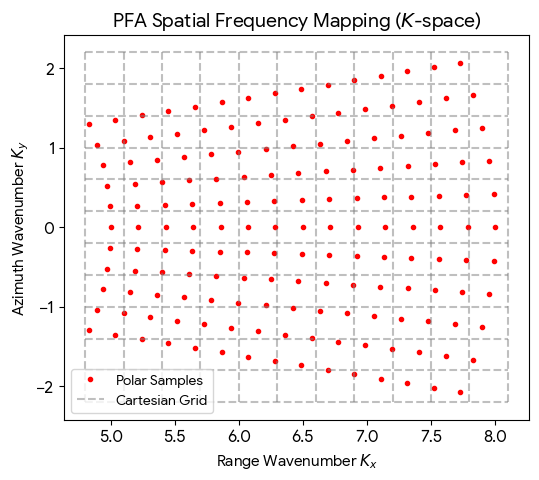

Decomposing each sample's k-space location into scene coordinates (range $k_x$, cross-range $k_y$):

$$k_x = \frac{4\pi f}{c_0}\cos\theta_p \qquad \qquad k_y = \frac{4\pi f}{c_0}\sin\theta_p$$

where $\theta_p$ is pulse $p$'s look angle within the slant plane. Rather than one expensive 2-D interpolation, the polar geometry factors into two passes of cheap 1-D interpolation:

1. **Range interpolation:** each pulse (a row of the data matrix) is uniformly sampled in $f$, i.e. _along_ its k-space spoke; resample each row onto a common uniform $k_x$ grid (the largest rectangle covered by every spoke).
2. **Azimuth interpolation:** after pass 1, the column at $k_x$ contains samples at $k_y = k_x\tan\theta_p$; resample each column onto a uniform $k_y$ grid.

The result is Fourier samples on a perfect rectangular lattice, so the image is one `fft2()` away, every pixel of the full scene drops out at once. That is the entire reason PFA is fast: for $N$ pulses of $N$ samples each, the interpolations cost $O(N^2)$ and the FFT $O(N^2\log N)$, versus backprojection's $O(N^3)$.

The price is the plane-wave approximation baked into the k-space model: real wavefronts are spherical, and the neglected quadratic term produces a _space-variant_ phase error that grows with distance from the SRP, progressively defocusing the edges of large scenes. A common rule of thumb (see Jakowatz et al., _Spotlight-Mode SAR: A Signal Processing Approach_) limits the well-focused scene radius to on the order of $\rho_a\sqrt{2R/\lambda_c}$, roughly 10 km for this geometry, so our 6 km swath is safe. Production processors also use high-quality windowed-sinc interpolation kernels; we use simple linear interpolation (`np.interp`) for clarity at the cost of a slightly elevated noise floor. Our angular aperture is tiny ($\Delta\theta \approx 0.54^\circ$, with $\approx 2\%$ fractional bandwidth), so the true annulus is already nearly rectangular and the resampling shifts are subtle.

In [ ]:
t_start = time.perf_counter()

kfac = 4*np.pi/c0
cos_t = np.cos(theta_p)
tan_t = np.tan(theta_p)
n_rf = np.arange(Nrf, dtype=np.float64)

# Pass 1 -- range interpolation: resample each pulse (row) from its native
# radial k-space locations kx = (4*pi*f/c0)*cos(theta) onto a common uniform
# kx grid (the largest grid covered by every pulse). Note np.interp handles
# complex-valued inputs.
kx_lo = (kfac*sc0_sub*cos_t).max()
kx_hi = (kfac*(sc0_sub + scss_sub*(Nrf - 1))*cos_t).min()
kx_u = np.linspace(kx_lo, kx_hi, Nrf)
pfa_s1 = np.empty((Np_sub, Nrf), dtype=np.complex64)
for p in range(Np_sub):
    kx_p = (kfac*cos_t[p])*(sc0_sub[p] + scss_sub[p]*n_rf)
    pfa_s1[p, :] = np.interp(kx_u, kx_p, cph_sub[p, :])

# Pass 2 -- azimuth interpolation: the column at kx_u[i] now holds samples at
# ky = kx_u[i]*tan(theta_p); resample each column onto a uniform ky grid.
col_min = np.minimum(kx_u*tan_t[0], kx_u*tan_t[-1])
col_max = np.maximum(kx_u*tan_t[0], kx_u*tan_t[-1])
ky_u = np.linspace(col_min.max(), col_max.min(), Np_sub)
pfa_s1t = np.ascontiguousarray(pfa_s1.T)   # contiguous columns for speed
del pfa_s1
pfa_s2 = np.empty((Np_sub, Nrf), dtype=np.complex64)
for i in range(Nrf):
    pfa_s2[:, i] = np.interp(ky_u, kx_u[i]*tan_t, pfa_s1t[i, :])
del pfa_s1t

# The regridded data are now rectangular samples of the scene's spectrum
# exp(+j*k.x), so a single 2-D FFT forms the entire image (the azimuth axis
# is zero-padded 2x for finer pixel sampling of the impulse response).
Ny_fft = 2*8192
img_pfa = sfft.fftshift(sfft.fft2(pfa_s2, s=(Ny_fft, Nrf), workers=-1))
del pfa_s2

t_pfa = time.perf_counter() - t_start

# Image-domain pixel spacings/axes follow from the k-space grid spacings.
dkx = (kx_hi - kx_lo)/(Nrf - 1)
dky = (ky_u[-1] - ky_u[0])/(Np_sub - 1)
pfa_dx = 2*np.pi/(Nrf*dkx)                  # range pixel spacing (m)
pfa_dy = 2*np.pi/(Ny_fft*dky)               # cross-range pixel spacing (m)
pfa_x = (np.arange(Nrf) - Nrf//2)*pfa_dx    # + toward the radar
pfa_y = (np.arange(Ny_fft) - Ny_fft//2)*pfa_dy

print(f"PFA: {img_pfa.shape[0]}x{img_pfa.shape[1]} px "
      f"({img_pfa.size/1e6:.0f} Mpix) in {t_pfa:.1f} s "
      f"-> {img_pfa.size/t_pfa/1e6:.0f} Mpix/s")
print(f"Pixel spacing: {pfa_dx:.2f} m (range) x {pfa_dy:.2f} m (cross-range)")

In [ ]:
# Display the full-swath PFA image. The display is normalized to a high
# percentile rather than the absolute peak: focusing concentrates the
# brightest scatterers (e.g. corner reflections off steel structures) so
# strongly that a peak-normalized image would look nearly black.
pfa_mag_full = np.abs(img_pfa)
pfa_ref = np.percentile(pfa_mag_full, 99.9)
pfa_db_full = 20*np.log10(np.minimum(pfa_mag_full/pfa_ref, 1.0) + 1e-10)
del pfa_mag_full

plt.figure(figsize=(12, 8), dpi=200)
plt.imshow(pfa_db_full.T, vmin=-50, vmax=0, cmap='gray', aspect='auto',
           origin='lower', extent=(pfa_y[0], pfa_y[-1], pfa_x[0], pfa_x[-1]))
plt.xlabel('Cross-range (meters)')
plt.ylabel('Slant-plane range offset, + toward radar (meters)')
plt.title(f'PFA image, full swath, formed in {t_pfa:.1f} s')
plt.show()

#### Backprojection (BP)

Backprojection skips the Fourier gymnastics entirely and implements the matched filter literally, one pixel at a time. There are only two steps:

1. **Range compression:** an IFFT across frequency turns each pulse into a _range profile_ of reflectivity versus round-trip delay. We zero-pad the IFFT ($8\times$) so the profile is finely sampled and linear interpolation between delay bins stays accurate.
2. **Coherent summation:** for every pixel position $\vec{q}$ in the output grid, compute the _exact_ differential delay to the true 3-D transmit/receive positions on every pulse, pull that delay's sample out of the range profile, remove the residual carrier phase, and accumulate:

$$I(\vec{q}) = \sum_{p} s_{rc}\big(p,\ \Delta\tau_p(\vec{q})\big)\, e^{\,j 2\pi f_{0,p} \Delta\tau_p(\vec{q})}, \qquad \Delta\tau_p(\vec{q}) = \frac{\lvert\vec{r}_{tx,p} - \vec{q}\rvert + \lvert\vec{r}_{rx,p} - \vec{q}\rvert}{c_0} - \tau_{ref,p}$$

where $f_{0,p}$ is the pulse's starting RF frequency (PVP `SC0` the frequency the delay-domain profile is referenced to) and $\tau_{ref,p}$ is the reference (SRP) delay the data was compensated to. If a scatterer really is at $\vec{q}$, every term of the sum lines up in phase and adds coherently ($N_{pulses}$-fold gain); returns from everywhere else integrate toward zero. It is a matched filter built per-pixel.

Because each delay is computed from the true spherical-wavefront geometry, BP makes essentially no approximations: no scene-size limit, exact focus everywhere, tolerance of arbitrary (well-measured) platform motion, and the output grid can be _anything_: slant plane, ground plane, or draped over a terrain model (DEM). The price is $O(N_{pulses} \times N_{pixels})$ compute: thousands of operations _per pixel_ versus PFA's handful. We therefore backproject only a small patch, and to make the comparison fair we use _exactly_ the central $512\times512$ pixel locations of the PFA image above. (_Fast Factorized Backprojection_ (Ulander et al.) recovers most of the speed by hierarchically combining subapertures, at a small accuracy cost.)

In [ ]:
t_start = time.perf_counter()

# Backproject onto the exact same slant-plane pixel locations as the central
# 512x512 patch of the PFA image, for a fair pixel-for-pixel comparison.
Npatch = 512
bp_ix = slice(Nrf//2 - Npatch//2, Nrf//2 + Npatch//2)
bp_iy = slice(Ny_fft//2 - Npatch//2, Ny_fft//2 + Npatch//2)
patch_x = pfa_x[bp_ix]
patch_y = pfa_y[bp_iy]
bp_pix = (srp_c[None, None, :]
          + patch_x[:, None, None]*x_hat[None, None, :]
          + patch_y[None, :, None]*y_hat[None, None, :]).reshape(-1, 3)

os_bp = 8                    # range-profile oversampling factor
Nup = os_bp*8192
df_hz = np.mean(scss_sub)    # RF frequency sample spacing (Hz)
img_bp = np.zeros(Npatch*Npatch, dtype=np.complex128)
chunk = 128
for a in range(0, Np_sub, chunk):
    b = min(a + chunk, Np_sub)
    # Range compression: a zero-padded IFFT across frequency turns each pulse
    # into a finely-sampled reflectivity-vs-delay (range) profile.
    rc = sfft.ifft(cph_sub[a:b, :], n=Nup, axis=1, workers=-1)
    for p in range(a, b):
        # Exact differential round-trip delay from this pulse's true Tx/Rx
        # positions to every pixel (no plane-wave approximation).
        dtau = (np.linalg.norm(tx_sub[p] - bp_pix, axis=1)
                + np.linalg.norm(rx_sub[p] - bp_pix, axis=1))/c0 - tref_sub[p]
        # Linearly interpolate the range profile at each pixel's delay. With
        # the e^{-j2pi*f*dtau} data convention, delay dtau lands at fractional
        # bin dtau*Nup*df of the IFFT output (negative delays wrap around).
        fbin = dtau*(Nup*df_hz)
        i0 = np.floor(fbin).astype(np.int64)
        frac = fbin - i0
        prof = rc[p - a]
        val = prof[i0 % Nup]*(1 - frac) + prof[(i0 + 1) % Nup]*frac
        # Remove the residual carrier phase (the IFFT profile is referenced
        # to the pulse start frequency SC0) and coherently accumulate.
        img_bp += val*np.exp(1j*2*np.pi*sc0_sub[p]*dtau)
img_bp = img_bp.reshape(Npatch, Npatch)

t_bp = time.perf_counter() - t_start
print(f"BP: {Npatch}x{Npatch} px ({img_bp.size/1e6:.2f} Mpix) over {Np_sub} "
      f"pulses in {t_bp:.1f} s -> {img_bp.size/t_bp/1e3:.1f} kpix/s")

#### Comparing PFA vs. BP

Because both images sample the identical slant-plane pixel grid, they can be compared directly:

- **Visually**, side-by-side at the same dB dynamic range.
- **Impulse response (IPR) cuts** through the brightest scatterer in the patch: the mainlobe width is the realized resolution, and sidelobe/floor levels show processing fidelity (interpolation error, residual phase error). No amplitude weighting was applied, so the ideal response is a $\mathrm{sinc}$ with $-13$ dB first sidelobes.
- **Contrast** (standard deviation over mean of pixel intensity where higher = sharper) and **entropy** (lower = sharper): the standard global sharpness metrics that autofocus algorithms optimize.
- **Throughput**: image pixels formed per second of compute time.

In [ ]:
# Side-by-side comparison over the exact same pixel grid and dynamic range.
pfa_patch = img_pfa[bp_iy, bp_ix].T          # reorder to [x, y] like img_bp
pfa_mag = np.abs(pfa_patch)
bp_mag = np.abs(img_bp).astype(np.float32)

fig, axs = plt.subplots(1, 2, figsize=(14, 7), dpi=150)
patch_ext = (patch_y[0], patch_y[-1], patch_x[0], patch_x[-1])
for ax, mag, name, t_alg in ((axs[0], pfa_mag, 'Polar Format Algorithm', t_pfa),
                             (axs[1], bp_mag, 'Backprojection', t_bp)):
    mag_db = 20*np.log10(mag/mag.max() + 1e-10)
    ax.imshow(mag_db, vmin=-50, vmax=0, cmap='gray', origin='lower',
              extent=patch_ext)
    ax.set_title(f'{name} ({t_alg:.1f} s)')
    ax.set_xlabel('Cross-range (meters)')
axs[0].set_ylabel('Slant-plane range offset, + toward radar (meters)')
plt.tight_layout()
plt.show()

In [ ]:
# Impulse response (IPR) cuts through the brightest scatterer in the patch
# (found in the BP image away from the edges), plus global focus metrics.
bp_search = bp_mag.copy()
bp_search[:16], bp_search[-16:], bp_search[:, :16], bp_search[:, -16:] = 0, 0, 0, 0
pk = np.unravel_index(np.argmax(bp_search), bp_search.shape)

fig, axs = plt.subplots(1, 2, figsize=(14, 4), dpi=150)
for ax, cut_axis, cut_pfa, cut_bp, label in (
        (axs[0], patch_x, pfa_mag[:, pk[1]], bp_mag[:, pk[1]], 'Range'),
        (axs[1], patch_y, pfa_mag[pk[0], :], bp_mag[pk[0], :], 'Cross-range')):
    ax.plot(cut_axis, 20*np.log10(cut_pfa/cut_pfa.max() + 1e-10), label='PFA')
    ax.plot(cut_axis, 20*np.log10(cut_bp/cut_bp.max() + 1e-10), label='BP')
    ctr = patch_x[pk[0]] if label == 'Range' else patch_y[pk[1]]
    ax.set_xlim(ctr - 20, ctr + 20)
    ax.set_ylim(-45, 1)
    ax.set_xlabel(f'{label} (meters)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'{label} IPR cut through brightest scatterer')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

def img_contrast(mag):
    """Normalized standard deviation of intensity (higher = sharper)."""
    inten = mag.astype(np.float64)**2
    return inten.std()/inten.mean()

def img_entropy(mag):
    """Shannon entropy of the intensity distribution (lower = sharper)."""
    pmf = mag.astype(np.float64)**2
    pmf /= pmf.sum()
    return -(pmf*np.log(pmf + 1e-30)).sum()

print(f"{'Metric':<28}{'PFA':>10}{'BP':>10}")
print(f"{'contrast (higher = focus)':<28}{img_contrast(pfa_mag):>10.2f}{img_contrast(bp_mag):>10.2f}")
print(f"{'entropy (lower = focus)':<28}{img_entropy(pfa_mag):>10.3f}{img_entropy(bp_mag):>10.3f}")
print(f"{'formation time (s)':<28}{t_pfa:>10.1f}{t_bp:>10.1f}")
print(f"{'throughput (Mpix/s)':<28}{img_pfa.size/t_pfa/1e6:>10.1f}{img_bp.size/t_bp/1e6:>10.4f}")

The two images are nearly indistinguishable near scene center which is good mutual validation that both implementations (and the k-space model behind them) are correct. Looking closer at the numbers:

- **Throughput:** PFA formed the entire ~134 Mpix swath in seconds; BP needed over a minute for a 0.26 Mpix patch, a per-pixel throughput gap of roughly _four orders of magnitude_, and one that widens with scene size.
- **Quality:** BP scores slightly better on contrast/entropy and has a marginally cleaner impulse response, since it makes no plane-wave approximation and suffers no k-space interpolation loss. Its real advantages appear where PFA's assumptions break down: very large scenes, wide angular apertures, highly curved or imperfect flight paths, and imaging directly onto terrain height models.
- **Practice:** operational processors pair a fast algorithm (PFA for spotlight, Range-Migration/$\omega$-k or Range-Doppler for stripmap) with an **autofocus** step (e.g. Phase Gradient Autofocus (PGA)) to estimate and remove residual phase errors that neither algorithm can predict from metadata alone, and reserve (fast factorized) backprojection for the hard geometries.

#### Improving PFA Further: Autofocus

The PFA image above came out essentially as sharp as backprojection for one big reason: Capella's orbit is smooth and known to centimeter level, so the metadata-driven motion compensation was nearly perfect. Airborne, and especially small/homebuilt, SAR platforms have no such luxury: turbulence, vibration, and GPS/INS drift leave _unmeasured_ line-of-sight motion $\delta r(t_p)$ between the assumed and true aperture positions, which adds a slow-time phase error to every scatterer:

$$\phi_{err}(t_p) = \frac{4\pi}{\lambda_c}\,\delta r(t_p)$$

The sensitivity is brutal: at X-band, ~4 mm of unmeasured motion is already $\pi/2$ of two-way phase, and a quadratic error exceeding roughly $\pi/4$ across the aperture visibly defocuses the image. Two structural facts make this correctable after the fact:

1. Since the scene is tiny compared to the standoff range, the error is (to good approximation) **common to every scatterer**; one unknown 1-D function of slow time multiplying the whole aperture.
2. It lives almost entirely in the **cross-range** dimension: in the (range, aperture) domain the data is multiplied by $e^{j\phi_{err}(t_p)}$, so the cross-range impulse response gets convolved with the Fourier transform of $e^{j\phi_{err}}$; cross-range smears while range stays sharp.

**Autofocus** estimates $\phi_{err}$ from the imagery itself. The classic estimator is **Phase Gradient Autofocus (PGA)** (Wahl, Eichel, Ghiglia & Jakowatz), built on a simple observation: an isolated point scatterer at the image origin _should_ have constant phase across the aperture, so whatever phase structure its response actually shows _is_ the error. Per iteration:

1. **Center:** in each of the strongest range bins, circularly shift the brightest scatterer to the origin column removing its own Doppler (i.e. its cross-range position, which would otherwise appear as a linear phase across the aperture).
2. **Window:** keep only a neighborhood around the origin, each surviving row is now a noisy copy of the common blur kernel.
3. **Estimate:** transform rows back to the aperture domain, where row $k$ is $g_k(t_p) \approx A_k(t_p)\,e^{j\phi_{err}(t_p)}$, and average the pulse-to-pulse *phase gradient* across rows:

$$\Delta\hat{\phi}(t_p) = \arg\Big\{ \sum_k g_k^*(t_{p-1})\, g_k(t_p) \Big\}$$

The conjugate product cancels each scatterer's own (constant) phase and amplitude-weights the average, leaving just the increment of the common error. This is in fact the maximum-likelihood estimator: integrate the gradient, remove the linear trend (a ramp only shifts the image), apply the conjugate correction, shrink the window, and repeat until it converges (typically a handful of iterations).

Our spaceborne image is already focused, so to demonstrate PGA honestly we **inject a known error**- an unmeasured quadratic acceleration plus a sinusoidal vibration, ~25 radians peak- then hand PGA only the corrupted image and see how well it blindly recovers both the imagery and the error itself:

In [ ]:
t_start = time.perf_counter()

def img_to_aperture(img_c):
    """Cross-range image axis -> centered slow-time (aperture) axis, per range bin."""
    return sfft.fftshift(sfft.ifft(img_c, axis=1), axes=1)

def aperture_to_img(g_k):
    return sfft.fft(sfft.ifftshift(g_k, axes=1), axis=1)

# Corrupt the PFA patch with a known slow-time phase error: an unmeasured
# quadratic acceleration plus a sinusoidal vibration (~25 rad peak, far past
# the ~pi/4 focus limit).
ap_ax = np.linspace(-1, 1, Npatch)
phi_true = 8*np.pi*ap_ax**2 + 3.0*np.sin(2*np.pi*1.5*ap_ax)
patch_corrupt = aperture_to_img(img_to_aperture(pfa_patch)*np.exp(1j*phi_true))

# --- Phase Gradient Autofocus ---
wrk = patch_corrupt.copy()
phi_hat = np.zeros(Npatch)
win_half = Npatch//4                    # window half-width, shrinks each pass
for _ in range(10):
    # 1) In the strongest range bins, circularly shift the brightest
    #    scatterer to the origin column. This removes its Doppler offset:
    #    a target at the origin has NO linear phase across the aperture, so
    #    any phase structure left is the common error.
    mags = np.abs(wrk)
    rows = np.argsort(mags.max(axis=1))[-128:]
    g_ctr = np.zeros((rows.size, Npatch), dtype=np.complex64)
    for i, r in enumerate(rows):
        g_ctr[i] = np.roll(wrk[r], -np.argmax(mags[r]))
    # 2) Window around the origin (wrapping both edges): what remains of
    #    each row is a noisy copy of the common cross-range blur kernel.
    g_ctr[:, win_half:Npatch - win_half] = 0
    # 3) Back in the aperture domain the kernel is ~ A(t)e^{j phi_err(t)}:
    #    estimate the pulse-to-pulse phase gradient jointly over all rows
    #    (the conjugate product cancels each scatterer's own phase), then
    #    integrate the gradient into a phase estimate.
    g_k = img_to_aperture(g_ctr)
    dphi = np.angle(np.sum(np.conj(g_k[:, :-1])*g_k[:, 1:], axis=0))
    phi = np.concatenate(([0.0], np.cumsum(dphi)))
    # A linear phase ramp is unobservable (it only shifts the image).
    phi -= np.polyval(np.polyfit(ap_ax, phi, 1), ap_ax)
    # 4) Apply the conjugate correction, shrink the window, repeat.
    wrk = aperture_to_img(img_to_aperture(wrk)*np.exp(-1j*phi))
    phi_hat += phi
    win_half = max(win_half//2, 4)
patch_pga = wrk
t_pga = time.perf_counter() - t_start

print(f"PGA converged in {t_pga:.1f} s")
print(f"contrast: original = {img_contrast(pfa_mag):.2f}, corrupted = "
      f"{img_contrast(np.abs(patch_corrupt)):.2f}, after PGA = "
      f"{img_contrast(np.abs(patch_pga)):.2f}")

fig, axs = plt.subplots(1, 3, figsize=(15, 5.4), dpi=150)
for ax, im_c, name in ((axs[0], pfa_patch, 'Original PFA patch'),
                       (axs[1], patch_corrupt, 'Corrupted ("unmeasured motion")'),
                       (axs[2], patch_pga, 'After PGA')):
    mag = np.abs(im_c)
    ax.imshow(20*np.log10(mag/mag.max() + 1e-10), vmin=-50, vmax=0,
              cmap='gray', origin='lower', extent=patch_ext)
    ax.set_title(name)
    ax.set_xlabel('Cross-range (meters)')
axs[0].set_ylabel('Slant-plane range offset (meters)')
plt.tight_layout()
plt.show()

# Compare the blind PGA estimate to the error we injected (both shown with
# linear trend removed, since a ramp is just a bulk image shift).
phi_true_d = phi_true - np.polyval(np.polyfit(ap_ax, phi_true, 1), ap_ax)
plt.figure(figsize=(10, 3.5), dpi=150)
plt.plot(ap_ax, phi_true_d, label='injected phase error')
plt.plot(ap_ax, phi_hat, '--', label='PGA estimate')
plt.xlabel('Normalized aperture position')
plt.ylabel('Phase (radians)')
plt.legend()
plt.grid(True)
plt.show()

PGA blindly recovers both the image and the error: the restored patch is essentially indistinguishable from the original (its contrast actually lands a touch _higher_, since the estimate also absorbs whatever small residual phase error the original image carried), and the estimated curve tracks the injected one to within a few radians, worst near the aperture edges, where the antenna beam taper leaves the phase only weakly constrained. Some other tactics from the autofocus & calibration toolbox:

- **Metric-driven (parametric) autofocus:** parameterize the error, polynomial phase coefficients, or the platform track itself and numerically optimize a global sharpness metric like the image **entropy** or **contrast** we computed earlier. Slower than PGA (each optimizer step re-forms the image) but it needs no isolated bright scatterers and can correct _position_ errors large enough to cause range cell migration, not just phase.
- **Map-drift:** form two low-resolution images from the two halves of the aperture; a quadratic phase error makes them shift relative to each other, so the peak of their cross-correlation directly measures the quadratic coefficient. A cheap, robust first pass before finer methods.
- **Autofocus as trajectory estimation:** for backprojected imagery there is no single aperture-domain FFT to correct, and a phase error is no longer common across a large scene. The fix is to run (generalized) PGA on many small _subimages_, convert each subimage's phase error into a line-of-sight distance error via $\Delta r = \frac{\lambda_c}{4\pi}\phi_{err}$, and, since each subimage views the platform from a different direction, solve a small least-squares system per pulse for the full 3-D trajectory correction $(\Delta x, \Delta y, \Delta z)$. [Henrik Forstén's drone SAR autofocus & calibration write-up](https://hforsten.com/synthetic-aperture-radar-autofocus-and-calibration.html) is a superb worked example: a 6 GHz FMCW quadcopter SAR whose GPS/INS-derived track is refined to ~0.1 wavelength RMS this way (GPU fast-factorized backprojection + autofocus in seconds, code in his [torchbp](https://github.com/Ttl/torchbp) package), taking imagery from visibly smeared to crisp.
- **Radiometric & hardware calibration:** autofocus can't fix systematic hardware effects, which that same article walks through for a homemade radar; normalizing antenna pattern and range roll-off to produce calibrated reflectivity ($\sigma^0$/$\beta^0$/$\gamma^0$), measuring frequency-dependent phase ripple through cables and filters, and solving polarimetric channel imbalance/crosstalk against a corner reflector of known radar cross-section. Commercial spaceborne products (like this CPHD) arrive largely pre-calibrated. The PVP fields we ignored (`TDTropoSRP`, `TDIonoSRP`, `AmpSF`) carry some of those corrections, but if you build your own radar, expect calibration to be half the project.

### SAR References

* I. G. Cumming and F. H. Wong, _Digital Processing of Synthetic Aperture Radar Data: Algorithms and Implementation_, Artech House, 2005.
* W. G. Carrara and R. M. Majewski and R. S. Goodman, _Spotlight Synthetic Aperture Radar: Signal Processing Algorithms_, Artech House, 1995.
* L. J. Cantafio, _Space-Based Radar Handbook_, Artech House, 1989.
* [Introduction to Synthetic Aperture Radar Using Python and MATLAB - GitHub](https://github.com/SARBook/software)
* [SAR 101: An Introduction to Synthetic Aperture Radar - Capella Space](https://www.capellaspace.com/sar-101-an-introduction-to-synthetic-aperture-radar/)
  + [SAR 201: An Introduction to Synthetic Aperture Radar, Part 2](https://medium.com/the-downlinq/sar-201-an-introduction-to-synthetic-aperture-radar-part-2-895beb0b4c0a)
* [Homemade Polarimetric SAR Drone - Henrik's Blog](https://hforsten.com/homemade-polarimetric-synthetic-aperture-radar-drone.html)
* [OSTI.gov](https://www.osti.gov/search/semantic:synthetic%20aperture%20radar)
  + [Basics of Polar-Format algorithm for processing Synthetic Aperture Radar images](https://www.osti.gov/biblio/1044949)
  + [Bistatic Synthetic Aperture Radar - Issues Analysis and Design](https://www.osti.gov/biblio/1669735)
  + [Generating nonlinear FM chirp waveforms for radar](https://www.osti.gov/biblio/894743)
  + [SAR processing with non-linear FM chirp waveforms](https://www.osti.gov/biblio/902597)
* [A Review of Synthetic-Aperture Radar Image Formation Algorithms and Implementations: A Computational Perspective](https://www.mdpi.com/2072-4292/14/5/1258)
* [Squinted Spotlight Synthetic Aperture Radar (SAR) Image Formation - MATLAB](https://www.mathworks.com/help/radar/ug/squinted-spotlight-sar-image-formation.html)
* [Stripmap Synthetic Aperture Radar (SAR) Image Formation - MATLAB](https://www.mathworks.com/help/radar/ug/stripmap-synthetic-aperture-radar-sar-image-formation.html)
* [Radar for Space Observation: Systems, Methods and Applications](https://www.mdpi.com/journal/remotesensing/special_issues/7C43H2J2V2)
* [Interference Mitigation for Synthetic Aperture Radar Based on Deep Residual Network](https://www.mdpi.com/2072-4292/11/14/1654)
* [Synthetic Impulse and Aperture Radar (SIAR): A Novel Multi‐Frequency MIMO Radar](https://onlinelibrary.wiley.com/doi/book/10.1002/9781118609576)
* [Sandia Pathfinder Radar ISR & SAR Systems](https://www.sandia.gov/radar/)


#### Open-Source SAR Repos

* https://github.com/RadarCODE/awesome-sar
* https://github.com/ron-kemker/sar
* https://github.com/AlexeyPechnikov/pygmtsar
  + https://insar.dev/
* https://github.com/insarlab/MintPy
* [Alaska Satellite Facility](https://asf.alaska.edu/)

## General Radar References

* [Introduction to Radar Using Python and MATLAB](https://github.com/RadarBook/software)
* [Build Your Own Radar - Jon Kraft YouTube Playlist](https://www.youtube.com/playlist?list=PLxC4LYGYcMqmPDEr8E8AlktQPcuHx4izm)
* [AERIS-10: Open Source Pulse Linear Frequency Modulated Phased Array Radar](https://github.com/NawfalMotii79/PLFM_RADAR)